# Raw-to-result tutorial 3 — Day-7 spatiotemporal Gata3

This notebook starts from the downloaded Day-7 RNA/guide H5 files and official
cell-type JSON. It reconstructs T/NK guide-source microregions, local distance
rings and NK-composition responses in two replicates. Coordinates are retained
in their validated **native units**; the tutorial never labels them as µm.

The DAPI archive is intentionally not overlaid because an image-to-bin transform
has not been verified. Tissue-bin coordinates provide the honest whole-section
background.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN
from IPython.display import display, Markdown

REPO = Path.cwd()
if not (REPO / "pyproject.toml").exists(): REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
DATA_ROOT = Path(os.environ.get("PERTURBRADIUS_DATA_ROOT", "/home/dataset-local/hulei/SpDiff/data"))
RAW = DATA_ROOT / "perturb_radius_spatiotemporal" / "extracted"
ARCHIVE = DATA_ROOT / "SPAC_spatiotemporal"
import perturbradius as pr
plt.rcParams.update({"font.size": 13, "axes.grid": False, "lines.linewidth": 1.7,
                     "figure.dpi": 120, "font.family": "DejaVu Sans"})
samples = ["Day7_rep1", "Day7_rep2"]
for sample in samples:
    assert (RAW / "Transcriptome" / f"{sample}.h5").exists()
    assert (RAW / "Perturbation" / f"{sample}.guide.h5").exists()
    assert (RAW / "Cell Type" / f"{sample}.annotation.json").exists()
print("Downloaded archives:", sorted(p.name for p in ARCHIVE.glob("*.zip")))
display(pr.h5_schema(RAW / "Perturbation/Day7_rep1.guide.h5").query(
    "dataset in ['X','obs/_index','var/_index','obsm/spatial']"))

Downloaded archives: ['Cell Type.zip', 'Cluster.zip', 'Mapping.zip', 'SPAC_DAPI_staining.zip', 'SPAC_perturbation.zip', 'SPAC_spatiotemporal.zip']


,dataset,shape,dtype
0,X,568003 × 34,int64
1,obs/_index,568003,object
4,obsm/spatial,568003 × 2,int64
5,var/_index,34,object


In [2]:
def call_day7_sample(sample):
    rna = pr.read_h5_axes(RAW / "Transcriptome" / f"{sample}.h5")
    with open(RAW / "Cell Type" / f"{sample}.annotation.json") as handle:
        annotation = json.load(handle)
    rna["cell_type"] = rna.barcode.map(annotation).fillna("Missing")
    calls, guide_names, matrix = pr.read_dense_guide_calls(
        RAW / "Perturbation" / f"{sample}.guide.h5", ntc_names=("sgnon-targeting",))
    calls = calls.merge(rna[["x","y","cell_type"]], on=["x","y"], how="left", validate="many_to_one")
    calls.cell_type = calls.cell_type.fillna("Missing")
    eligible = calls.cell_type.isin(["T","NK"]).to_numpy()
    posterior, neighbors, posterior_qc = pr.empirical_source_posteriors(
        matrix, eligible, calls[["x","y"]].to_numpy(), neighbor_radius=60)
    calls["source_posterior"], calls["same_guide_neighbors"] = posterior, neighbors
    calls["primary"] = (calls.guide_total >= 1) & (calls.top_fraction >= .70) & eligible
    calls["strict"] = (calls.guide_total >= 2) & (calls.top_fraction >= .70) & eligible

    # Raw primary calls -> per-guide spatial microregions.
    anchors, member_parts, serial = [], [], 0
    for guide, group in calls[calls.primary].groupby("top_guide"):
        labels = DBSCAN(eps=30, min_samples=1).fit_predict(group[["x","y"]])
        for label in sorted(set(labels)):
            serial += 1; part = group[labels == label].copy(); anchor = f"{sample}_A{serial:05d}"
            part["anchor_id"] = anchor; member_parts.append(part)
            anchors.append({"anchor_id": anchor, "sample": sample, "guide": guide,
                            "center_x": part.x.mean(), "center_y": part.y.mean(),
                            "source_bins": len(part), "strict_fraction": part.strict.mean(),
                            "posterior_max": part.source_posterior.max(),
                            "source_cell_type": part.cell_type.mode().iloc[0]})
    anchors, members = pd.DataFrame(anchors), pd.concat(member_parts, ignore_index=True)
    evidence = anchors[(anchors.source_bins >= 2) | (anchors.strict_fraction > 0)].copy().reset_index(drop=True)
    xy, guides = evidence[["center_x","center_y"]].to_numpy(), evidence.guide.to_numpy()
    neighbors = cKDTree(xy).query_ball_point(xy, 80)
    competing = np.asarray([any(guides[j] != guides[i] for j in near) for i, near in enumerate(neighbors)], dtype=bool)
    evidence = evidence.loc[~competing].copy()
    keep = []
    for guide, group in evidence.groupby("guide"):
        group = group.sort_values(["source_bins","strict_fraction","posterior_max"], ascending=False)
        chosen = []
        for index, row in group.iterrows():
            point = np.asarray([row.center_x,row.center_y])
            if chosen and np.min(np.linalg.norm(np.asarray(chosen)-point,axis=1)) < 160: continue
            keep.append(index); chosen.append(point)
    evidence = evidence.loc[keep].copy(); evidence["patch_id"] = evidence.anchor_id.str.replace("_A","_P")
    members = members[members.anchor_id.isin(evidence.anchor_id)].copy()

    # Composition in 40–80, 80–120, 120–160 and 160–240 native-unit rings.
    tree = cKDTree(rna[["x","y"]]); source_xy = set(map(tuple, members[["x","y"]].to_numpy()))
    rows = []
    for row in evidence[evidence.guide.isin(["sgGata3","sgnon-targeting"])].itertuples():
        index = np.asarray(tree.query_ball_point([row.center_x,row.center_y],240), dtype=int)
        local = rna.iloc[index].copy()
        local["distance"] = np.linalg.norm(local[["x","y"]].to_numpy()-[row.center_x,row.center_y],axis=1)
        is_source = np.asarray([tuple(point) in source_xy for point in local[["x","y"]].to_numpy()])
        local = local.loc[~is_source]
        for low, high in zip([40,80,120,160],[80,120,160,240]):
            ring = local[(local.distance >= low) & (local.distance < high)]
            rows.append({"sample":sample,"patch_id":row.patch_id,"anchor_id":row.anchor_id,
                         "guide":row.guide,"center_x":row.center_x,"center_y":row.center_y,
                         "ring_low":low,"ring_high":high,"ring_mid":(low+high)/2,
                         "fraction_NK":ring.cell_type.eq("NK").mean(),"n_bins":len(ring)})
    return rna, calls, evidence, members, pd.DataFrame(rows)

packs = {sample: call_day7_sample(sample) for sample in samples}
anchors = pd.concat([packs[s][2] for s in samples], ignore_index=True)
rings = pd.concat([packs[s][4] for s in samples], ignore_index=True)
display(anchors.groupby(["sample","guide"]).size().loc[:, ["sgGata3","sgnon-targeting"]].rename("supported_patches").to_frame())

supported_patches
sample    guide                             
Day7_rep1 sgGata3                         32
          sgnon-targeting                 38
Day7_rep2 sgGata3                         51
          sgnon-targeting                 12

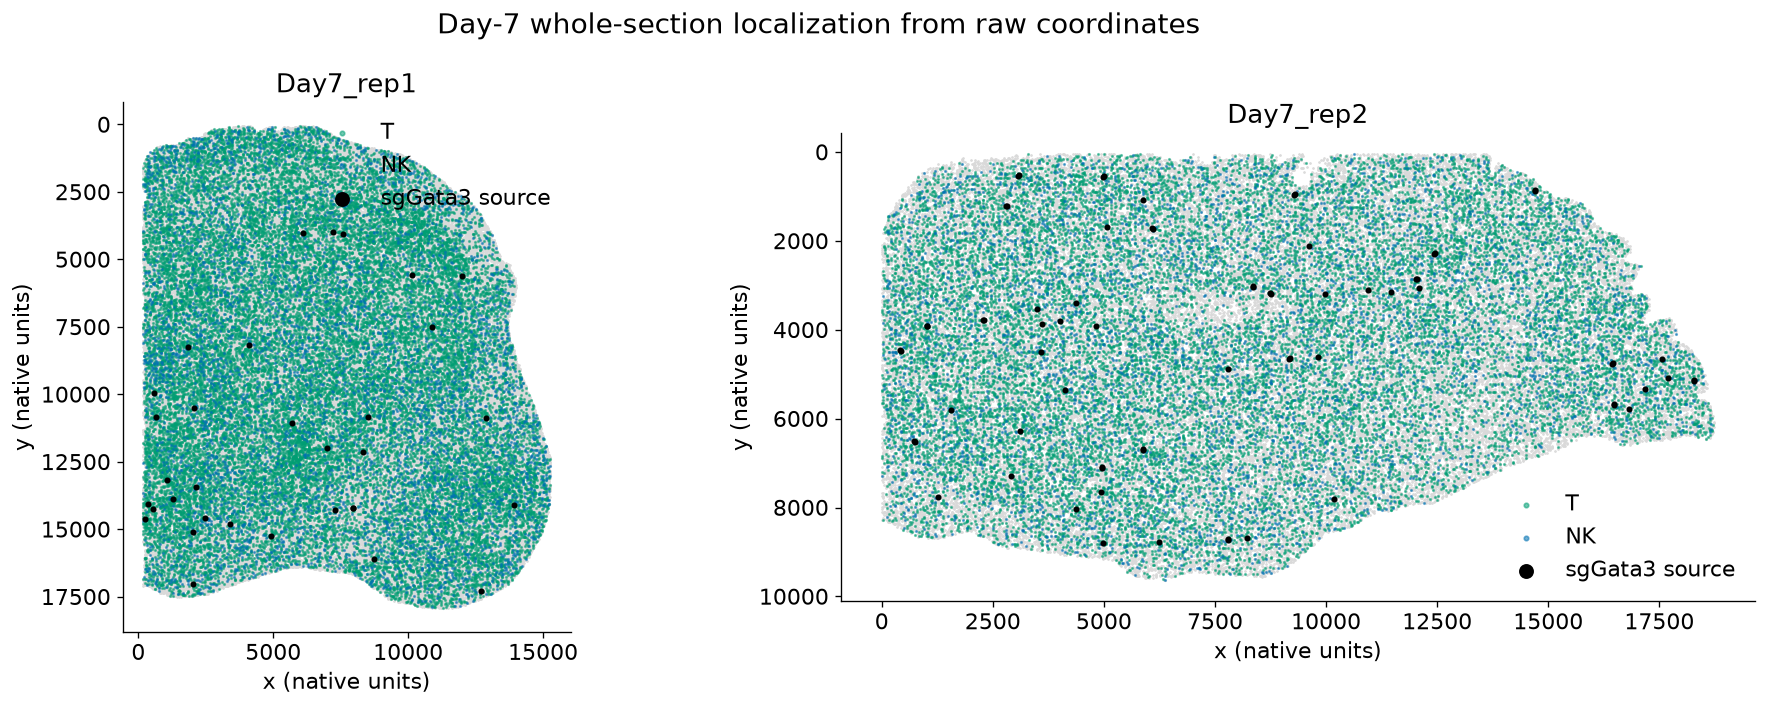

In [3]:
# Whole-section tissue-bin view: official NK/T labels and Gata3 source patches.
fig, axes = plt.subplots(1,2,figsize=(16,6))
for ax, sample in zip(axes,samples):
    rna, calls, evidence, members, response = packs[sample]
    background = rna.iloc[::6]
    ax.scatter(background.x, background.y, s=.35, color="#D9D9D9", rasterized=True)
    for cell_type, color in [("T","#009E73"),("NK","#0072B2")]:
        group = rna[rna.cell_type.eq(cell_type)].iloc[::2]
        ax.scatter(group.x,group.y,s=.8,color=color,alpha=.55,rasterized=True,label=cell_type)
    gata_ids = set(evidence.loc[evidence.guide.eq("sgGata3"),"anchor_id"])
    src = members[members.anchor_id.isin(gata_ids)]
    ax.scatter(src.x,src.y,s=7,color="black",rasterized=True,label="sgGata3 source")
    ax.set_title(sample); ax.set_xlabel("x (native units)"); ax.set_ylabel("y (native units)")
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.spines[["top","right"]].set_visible(False)
    ax.legend(frameon=False,markerscale=3)
fig.suptitle("Day-7 whole-section localization from raw coordinates",fontsize=17)
fig.tight_layout();plt.show()

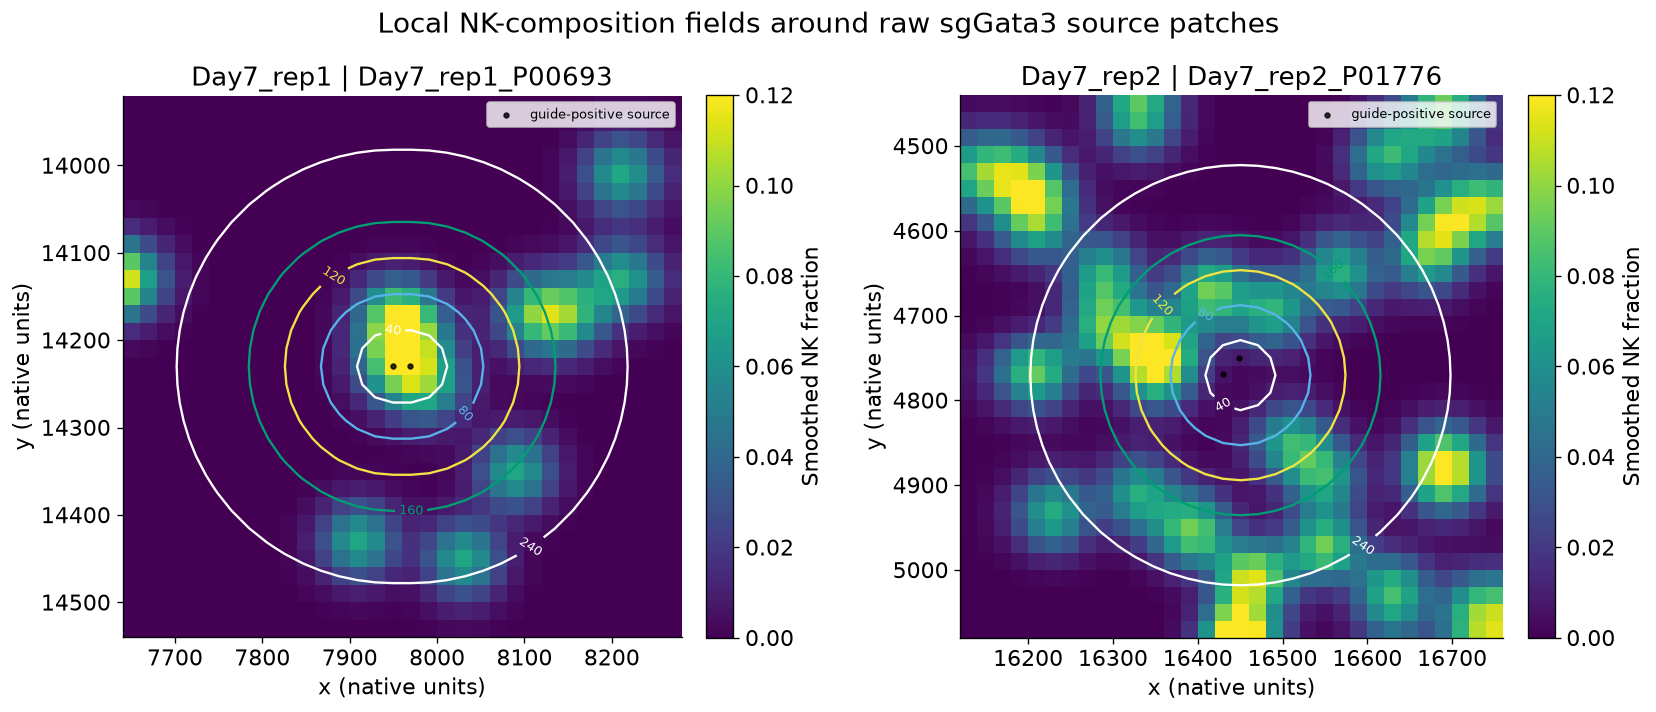

In [4]:
# Representative local NK response map from each replicate.
fig, axes = plt.subplots(1,2,figsize=(14,6))
for ax,sample in zip(axes,samples):
    rna,calls,evidence,members,response = packs[sample]
    chosen = evidence[evidence.guide.eq("sgGata3")].sort_values("source_bins",ascending=False).iloc[0]
    source = members[members.anchor_id.eq(chosen.anchor_id)].rename(columns={"x":"x_um","y":"y_um"})
    local_data = rna.rename(columns={"x":"x_um","y":"y_um"}).copy()
    local_data["nk_indicator"] = local_data.cell_type.eq("NK").astype(float)
    pr.plot_local_response(local_data, source, response_col="nk_indicator", resolution=20,
                           pad=300, sigma_bins=1.5, contour_levels=(40,80,120,160,240),
                           ax=ax, title=f"{sample} | {chosen.patch_id}", cbar_label="Smoothed NK fraction",
                           coordinate_label="native units", cmap="viridis", value_limits=(0,.12))
fig.suptitle("Local NK-composition fields around raw sgGata3 source patches",fontsize=17)
fig.tight_layout();plt.show()

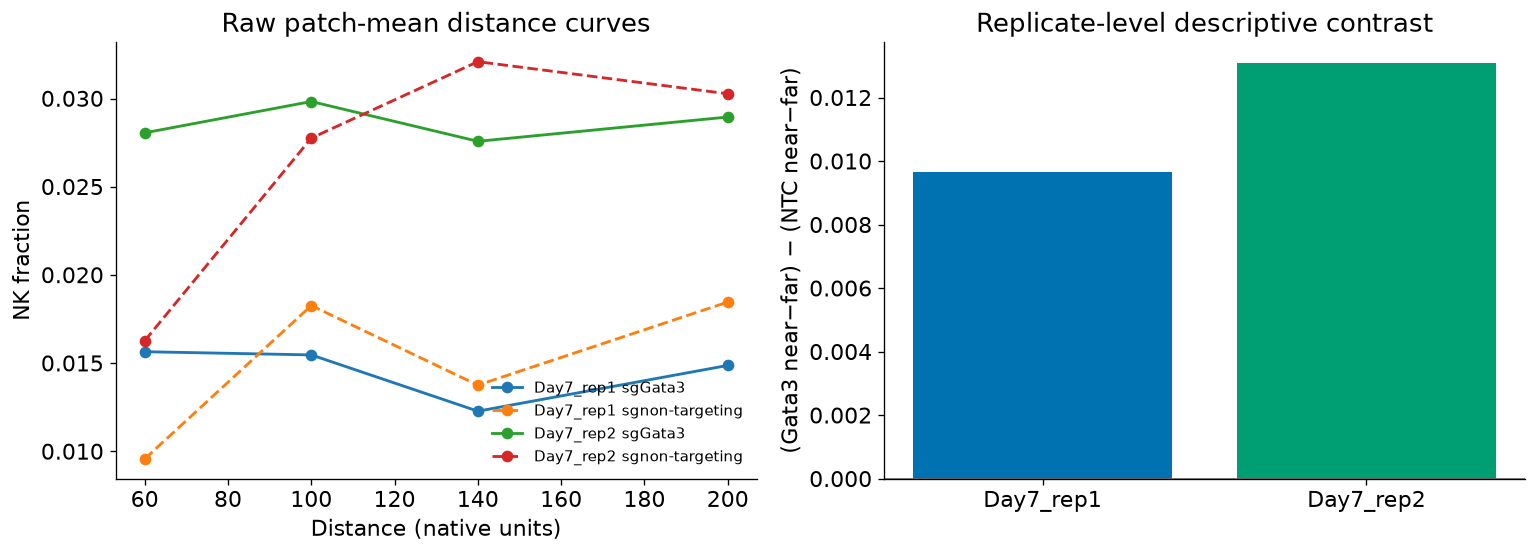

,sample,guide,patches,near_minus_far
0,Day7_rep1,sgGata3,32,0.000777
1,Day7_rep1,sgnon-targeting,38,-0.008891
2,Day7_rep2,sgGata3,51,-0.000895
3,Day7_rep2,sgnon-targeting,12,-0.014000


guide,sgGata3,sgnon-targeting,Gata3_minus_NTC
sample,,,
Day7_rep1,0.000777,-0.008891,0.009669
Day7_rep2,-0.000895,-0.014000,0.013105


In [5]:
# Raw curves and replicate-level difference-in-differences against NTC patches.
summary = (rings.groupby(["sample","guide","ring_low","ring_mid"],as_index=False)
           .agg(fraction_NK=("fraction_NK","mean"), patches=("patch_id","nunique")))
contrasts=[]
for (sample,guide),group in rings.groupby(["sample","guide"]):
    wide=group.pivot(index="patch_id",columns="ring_low",values="fraction_NK").dropna()
    contrasts.append({"sample":sample,"guide":guide,"patches":len(wide),
                      "near_minus_far":(wide[40]-wide[160]).mean()})
contrasts=pd.DataFrame(contrasts)
did=(contrasts.pivot(index="sample",columns="guide",values="near_minus_far")
     .assign(Gata3_minus_NTC=lambda x:x["sgGata3"]-x["sgnon-targeting"]))
fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for (sample,guide),group in summary.groupby(["sample","guide"]):
    style="-" if guide=="sgGata3" else "--"
    axes[0].plot(group.ring_mid,group.fraction_NK,marker="o",linestyle=style,label=f"{sample} {guide}")
axes[0].set_xlabel("Distance (native units)");axes[0].set_ylabel("NK fraction");axes[0].set_title("Raw patch-mean distance curves")
axes[0].legend(frameon=False,fontsize=9)
axes[1].bar(did.index,did.Gata3_minus_NTC,color=["#0072B2","#009E73"]);axes[1].axhline(0,color="#777",lw=1)
axes[1].set_ylabel("(Gata3 near−far) − (NTC near−far)");axes[1].set_title("Replicate-level descriptive contrast")
for ax in axes:ax.spines[["top","right"]].set_visible(False)
fig.tight_layout();plt.show()
display(contrasts);display(did)

In [6]:
display(Markdown(f"""
### Interpretation

Raw-data reconstruction yields **{int((anchors.guide=='sgGata3').sum())} sgGata3 patches** and
**{int((anchors.guide=='sgnon-targeting').sum())} NTC patches** across two Day-7 replicates. The
Gata3-minus-NTC near–far contrast is positive in both replicates
({did.Gata3_minus_NTC.iloc[0]:.4f}, {did.Gata3_minus_NTC.iloc[1]:.4f}), consistent with a small
local increase in NK fraction relative to the spatial NTC background.

This remains a **candidate**, not a radius: the effect is small, source/NTC coverage is imbalanced,
the validated units are not µm, and the prior full permutation screen did not pass global FDR.
The whole-section and patch maps show where the estimate originates; they do not upgrade the
statistical evidence.
"""))


### Interpretation

Raw-data reconstruction yields **83 sgGata3 patches** and
**50 NTC patches** across two Day-7 replicates. The
Gata3-minus-NTC near–far contrast is positive in both replicates
(0.0097, 0.0131), consistent with a small
local increase in NK fraction relative to the spatial NTC background.

This remains a **candidate**, not a radius: the effect is small, source/NTC coverage is imbalanced,
the validated units are not µm, and the prior full permutation screen did not pass global FDR.
The whole-section and patch maps show where the estimate originates; they do not upgrade the
statistical evidence.
